# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [1]:
# Task 0.1 — verify configuration loads from .env (no secrets printed)
from config import get_settings

s = get_settings()
print("host:       ", s["host"])
print("model:      ", s["model"])
print("embeddings: ", s["embeddings"])
print("vs_endpoint:", s["vs_endpoint"])
print("vs_index:   ", s["vs_index"])
print("token set:  ", bool(s["token"]))

host:        https://dbc-70e1cecd-4a2a.cloud.databricks.com
model:       databricks-meta-llama-3-3-70b-instruct
embeddings:  databricks-gte-large-en
vs_endpoint: 27100082-vs-endpoint
vs_index:    27100082_pa4.default.27100082_analyst_index
token set:   True


In [2]:
# Task 0.3 — corpus ingestion.
# NOTE: build_chunks_table() runs INSIDE a Databricks notebook (it needs Spark plus the
# ai_parse_document / ai_prep_search SQL functions). It was executed there once to build
# the Delta chunks table and the Vector Search index:
#
#     from rag.ingest import ingest
#     ingest(spark, "/Volumes/27100082_pa4/default/pa4/annual_report.pdf")
#
# Here we VERIFY the resulting index answers a similarity query from the client side.
# The same managed index is reachable identically from the laptop and from the deployed
# serving container (that is the point of going all-Databricks in Task 0.3).
from rag.ingest import similarity_test

_ = similarity_test("What was Meridian's net revenue in FY2023?", k=4)

d:\lums\Agentic AI\PA4\cs4603-pa4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


[ingest] query: "What was Meridian's net revenue in FY2023?" -> 4 hits
  - p4.0 [annual_report.pdf]: 
Gross profit improved to ¥3,350 billion as pricing and mix more than offset higher input costs. The effective tax rate ...
  - p0.0 [annual_report.pdf]: 
Annual Report

For the fiscal year ended March 31, 2023 (FY2023)

Tokyo Stock Exchange (Prime Market) · Code 7000

<tab...
  - p1.0 [annual_report.pdf]: 
All figures in this report are fictional and provided solely for CS4603 coursework.

To our shareholders, customers, an...
  - p6.0 [annual_report.pdf]: 
The Automobile segment's operating margin of 4.3% reflects continued investment in electrification and elevated logisti...


## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [3]:
# Task 1.7 — build the compiled graph (real LLM + Vector Search retriever + MCP tools)
from agent.graph import build_graph

graph = build_graph()
print("Compiled graph:", type(graph).__name__)
print("Nodes:", list(graph.get_graph().nodes))

Compiled graph: CompiledStateGraph
Nodes: ['__start__', 'planner', 'supervisor', 'rag_agent', 'mcp_tools', 'synthesizer', '__end__']


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	supervisor(supervisor)
	rag_agent(rag_agent)
	mcp_tools(mcp_tools)
	synthesizer(synthesizer)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	mcp_tools --> supervisor;
	planner --> supervisor;
	rag_agent --> supervisor;
	supervisor -.-> mcp_tools;
	supervisor -.-> rag_agent;
	supervisor -.-> synthesizer;
	synthesizer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



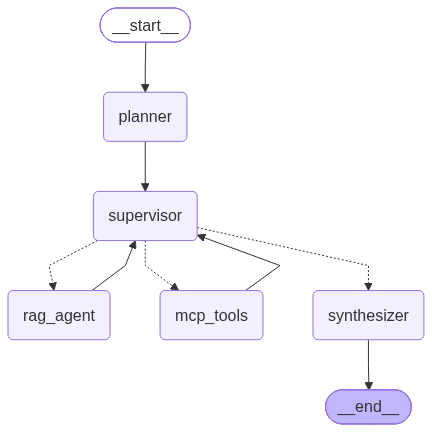

In [4]:
# Task 1.7 — visualize the compiled graph
from IPython.display import Image, display

print(graph.get_graph().draw_mermaid())  # text form (always available)
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("\n(PNG render skipped:", e, ")")

### Test the graph


In [5]:
# Retrieval-only query
r = graph.invoke({'messages':[{'role':'user','content':'What was the net income in 2023?'}]})
print("PLAN:  ", r["plan"])
print("ANSWER:", r["messages"][-1].content)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN:   ["Find the company's net income for fiscal year 2023"]
ANSWER: The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.3].


In [6]:
# Computation-only query
r = graph.invoke({'messages':[{'role':'user','content':'What is 15% of 2.4 billion?'}]})
print("PLAN:  ", r["plan"])
print("ANSWER:", r["messages"][-1].content)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN:   ['Find the value of 2.4 billion', 'Calculate 15% of that value']
ANSWER: 15% of 2.4 billion is 0.36 billion.


In [7]:
# Combined query — show the full step-by-step execution trace
r = graph.invoke({'messages':[{'role':'user','content':'What was the revenue in 2023, and what would a 10% increase look like?'}]})
print("PLAN:")
for i, step in enumerate(r["plan"]):
    print(f"  {i}. {step}")
print("\nSTEP RESULTS (execution trace):")
for sr in r["step_results"]:
    print("  -", sr)
print("\nFINAL ANSWER:", r["messages"][-1].content)

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


PLAN:
  0. Find the company's revenue for fiscal year 2023
  1. Calculate a 10% increase from the 2023 revenue

STEP RESULTS (execution trace):
  - Step 'Find the company's revenue for fiscal year 2023': Net revenue was ¥16,910 billion (¥16.91 trillion) [source: annual_report.pdf, p.1]
  - Step 'Calculate a 10% increase from the 2023 revenue': 16.91 * 1.1 = 18.601

FINAL ANSWER: The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.1]. A 10% increase would be ¥18.601 trillion.


### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [8]:
# Required offline smoke test (mocked LLM, no Databricks) — same test Bonus A runs
import sys, subprocess
print(subprocess.run([sys.executable, '-m', 'pytest', 'tests/test_smoke.py', '-q'],
                     capture_output=True, text=True).stdout)

..                                                                       [100%]



## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [1]:
# Task 2.1 — the models-from-code definition imports cleanly and is self-contained
# (validates env vars, rebuilds the graph with LLM + Vector Search retriever + MCP tools).
import subprocess, sys
r = subprocess.run([sys.executable, '-c',
                    'import deployment.agent_model; print("deployment.agent_model imported OK")'],
                   capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-800:])

deployment.agent_model imported OK


In [2]:
# Task 2.2 — logged with mlflow.langchain.log_model (models-from-code) + registered in UC.
# Run from the 3.12 deploy env:  python deployment/deploy.py --skip-secrets
#   log_model(lc_model='deployment/agent_model.py', name='agent',
#             code_paths=['agent','rag','tools','config.py'], pip_requirements=[...pinned...])
#   -> mlflow.register_model(...) into 27100082_pa4.default.document_analyst
# Evidence: list the registered Unity Catalog model versions via REST.
import json, urllib.request
from config import get_settings
s = get_settings(); H = {'Authorization': f"Bearer {s['token']}"}
req = urllib.request.Request(
    s['host'] + '/api/2.1/unity-catalog/models/27100082_pa4.default.document_analyst/versions', headers=H)
with urllib.request.urlopen(req, timeout=30) as x:
    data = json.loads(x.read())
vers = sorted(int(v['version']) for v in data.get('model_versions', []))
print('Registered UC model: 27100082_pa4.default.document_analyst')
print('Versions:', vers)

Registered UC model: 27100082_pa4.default.document_analyst
Versions: [1, 2, 3, 4, 5, 6]


In [3]:
# Task 2.3 — Serving endpoint state (READY) + served model version, via REST.
import json, urllib.request
from config import get_settings
s = get_settings(); H = {'Authorization': f"Bearer {s['token']}"}
req = urllib.request.Request(s['host'] + '/api/2.0/serving-endpoints/27100082-document-analyst', headers=H)
with urllib.request.urlopen(req, timeout=30) as x:
    d = json.loads(x.read())
print('Endpoint:', d['name'])
print('State:   ', d['state'])
for se in (d.get('config') or {}).get('served_entities', []):
    print('Serving: ', se['entity_name'], 'version', se['entity_version'])
print('URL:     ', f"{s['host']}/serving-endpoints/27100082-document-analyst/invocations")

Endpoint: 27100082-document-analyst
State:    {'ready': 'READY', 'config_update': 'NOT_UPDATING', 'suspend': 'NOT_SUSPENDED', 'system_update_failure': False}
Serving:  27100082_pa4.default.document_analyst version 6
URL:      https://dbc-70e1cecd-4a2a.cloud.databricks.com/serving-endpoints/27100082-document-analyst/invocations


### Test the deployed endpoint (Task 2.4)


In [4]:
# Task 2.4 (1) — call the deployed endpoint and show the RAW response.
# Shape = Path A: raw LangGraph state as a one-element batch LIST (mlflow.langchain.log_model).
# Parse via:  data[0]['messages'][-1]['content']   (the OpenAI .choices shape does NOT apply)
import json, urllib.request
from config import get_settings
s = get_settings()
url = f"{s['host']}/serving-endpoints/27100082-document-analyst/invocations"
H = {'Authorization': f"Bearer {s['token']}", 'Content-Type': 'application/json'}
body = json.dumps({'messages':[{'role':'user','content':'What was the net income in 2023?'}]}).encode()
with urllib.request.urlopen(urllib.request.Request(url, headers=H, data=body), timeout=120) as x:
    raw = json.loads(x.read())
print('type:', type(raw).__name__)
print('RAW (truncated):', json.dumps(raw)[:500])
print('\nPARSED ANSWER:', raw[0]['messages'][-1]['content'])

type: list
RAW (truncated): [{"messages": [{"content": "What was the net income in 2023?", "additional_kwargs": {}, "response_metadata": {}, "type": "human", "name": null, "id": "fb8e2548-2514-4f6a-925f-a2d6c8790688"}, {"content": "The net income in 2023 was \u00a51,107 billion [source: annual_report.pdf, p.3].", "additional_kwargs": {}, "response_metadata": {}, "type": "ai", "name": null, "id": "1d9220e8-6781-400b-b6b3-58623ce8a8e6", "tool_calls": [], "invalid_tool_calls": [], "usage_metadata": null}], "plan": ["Find the 

PARSED ANSWER: The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.3].


In [5]:
# Task 2.4 (2-5) — 3 query types on the deployed endpoint, latency, local-vs-deployed.
import json, time, urllib.request
from config import get_settings
s = get_settings()
URL = f"{s['host']}/serving-endpoints/27100082-document-analyst/invocations"
H = {'Authorization': f"Bearer {s['token']}", 'Content-Type': 'application/json'}
QUERIES = {
    'retrieval-only':   'What was the net income in 2023?',
    'computation-only': 'What is 15% of 2.4 billion?',
    'combined':         'What was the revenue in 2023, and what would a 10% increase look like?',
}
def call(q):
    body = json.dumps({'messages':[{'role':'user','content':q}]}).encode()
    t0 = time.time()
    with urllib.request.urlopen(urllib.request.Request(URL, headers=H, data=body), timeout=120) as x:
        data = json.loads(x.read())
    return data[0]['messages'][-1]['content'], time.time()-t0

print('=== Deployed endpoint — 3 query types ===')
deployed = {}
for label, q in QUERIES.items():
    ans, dt = call(q); deployed[label] = ans
    print(f'\n[{label}] ({dt:.1f}s)\n  Q: {q}\n  A: {ans}')

print('\n=== Latency (warm) — 3 sequential calls ===')
warm = [call(QUERIES['retrieval-only'])[1] for _ in range(3)]
for i, dt in enumerate(warm, 1): print(f'  call {i}: {dt:.2f}s')
print(f'  warm avg: {sum(warm)/len(warm):.2f}s  |  cold start (post scale-to-zero) is tens of s')

print('\n=== Local vs Deployed ===')
from agent.graph import build_graph
graph = build_graph()
for label, q in QUERIES.items():
    local = graph.invoke({'messages':[{'role':'user','content':q}]})['messages'][-1].content
    verdict = 'IDENTICAL' if local.strip()==deployed[label].strip() else 'DIFFERENT (LLM phrasing)'
    print(f'[{label}] -> {verdict}')

=== Deployed endpoint — 3 query types ===



[retrieval-only] (4.7s)
  Q: What was the net income in 2023?
  A: The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.3].



[computation-only] (7.0s)
  Q: What is 15% of 2.4 billion?
  A: 15% of 2.4 billion is 0.36 billion.



[combined] (10.6s)
  Q: What was the revenue in 2023, and what would a 10% increase look like?
  A: The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.1]. A 10% increase would be ¥18.601 trillion.

=== Latency (warm) — 3 sequential calls ===


  call 1: 3.76s
  call 2: 5.21s
  call 3: 5.95s
  warm avg: 4.97s  |  cold start (post scale-to-zero) is tens of s

=== Local vs Deployed ===


...

[retrieval-only] -> IDENTICAL


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


[computation-only] -> IDENTICAL


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


[combined] -> IDENTICAL


## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [1]:
# Task 3.2 (1-3) — instantiate the client, health-check, and ask.
import config  # loads .env so the client reads DATABRICKS_HOST/DATABRICKS_TOKEN
from client.sdk import DocumentAnalystClient

client = DocumentAnalystClient('27100082-document-analyst')  # host/token from env
assert client.health_check() is True, 'endpoint is not READY'
print('health_check():', client.health_check())
print('ask():', client.ask('What was the net income in 2023?'))

health_check(): True


ask(): The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.3].


In [2]:
# Task 3.2 (4) — ask_streaming(): print chunks as they arrive.
# Our models-from-code endpoint does not emit token deltas, so the client falls
# back to yielding the full answer once (a valid single-chunk outcome).
print('streaming chunks:')
for i, chunk in enumerate(client.ask_streaming('What was the revenue in 2023?'), 1):
    print(f'  chunk {i}: {chunk}')

streaming chunks:


  chunk 1: The revenue in 2023 was ¥16,910 billion [source: annual_report.pdf, p.3].


In [3]:
# Task 3.2 (5-6) — error handling: timeout, then retry-on-unavailable.
from client.sdk import DocumentAnalystClient, AnalystClientError

# (5) Simulate a timeout with an impossibly small timeout.
try:
    DocumentAnalystClient('27100082-document-analyst', timeout=0.001).ask('hi')
except TimeoutError as e:
    print('timeout handled ->', e)

# (6) Simulate the endpoint being unavailable (HTTP 503) and show exponential-backoff
# retries. We patch the HTTP call to always return 503 and count the attempts.
import client.sdk as sdk
calls = {'n': 0}
class _Resp503:
    status_code = 503
    headers = {'x-request-id': 'demo-req-123'}
    text = 'endpoint is scaling'
    reason_phrase = 'Service Unavailable'
    def json(self): return {'message': 'endpoint is scaling'}
orig_post, orig_sleep = sdk.httpx.post, sdk.time.sleep
sdk.httpx.post = lambda *a, **k: (calls.__setitem__('n', calls['n'] + 1) or _Resp503())
sdk.time.sleep = lambda s: None  # skip the real backoff waits in the demo
try:
    DocumentAnalystClient('x', host='https://h', token='t', max_retries=3).ask('hi')
except AnalystClientError as e:
    print(f'retry handled -> {calls["n"]} attempts (1 + 3 retries), '
          f'status={e.status_code}, request_id={e.request_id}')
finally:
    sdk.httpx.post, sdk.time.sleep = orig_post, orig_sleep

timeout handled -> Request to '27100082-document-analyst' timed out after 0.172s (timeout=0.001s).
retry handled -> 4 attempts (1 + 3 retries), status=503, request_id=demo-req-123
